# Data preprocessing

## Imports

In [23]:
!pip install numpy scikit-learn pandas matplotlib joblib

In [25]:
import numpy as np
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Download dataset

Use sklear method to load data set

In [4]:
dataset = load_breast_cancer(as_frame=True)

Convert to data frame for convenience

In [5]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

There's no missing values -- that good

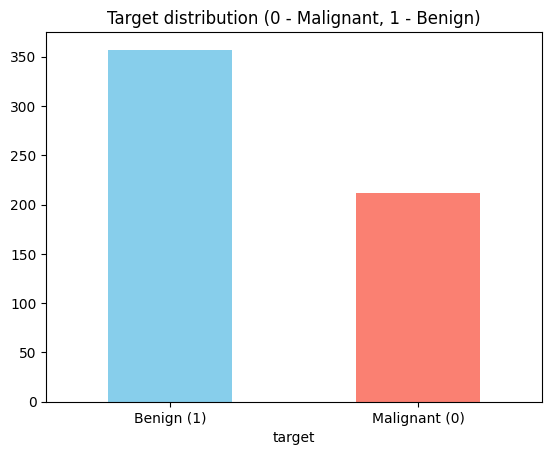

In [8]:
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], rot=0)

plt.title('Target distribution (0 - Malignant, 1 - Benign)')
plt.xticks(ticks=[0, 1], labels=['Benign (1)', 'Malignant (0)'])
plt.show()

Classes are unbalanced

## Train test split

In [9]:
X = df.drop('target', axis=1)
y = df['target']

In [10]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

In [11]:
print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")


Train size: 341
Val size: 114
Test size: 114


## Data normalization

In [12]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train).astype(np.float32, copy=False)

X_val = scaler.transform(X_val).astype(np.float32, copy=False)
X_test = scaler.transform(X_test).astype(np.float32, copy=False)

In [14]:
feature_cols = df.drop('target', axis=1).columns


In [15]:
train_df = pd.DataFrame(X_train, columns=feature_cols)
val_df = pd.DataFrame(X_val, columns=feature_cols)
test_df = pd.DataFrame(X_test, columns=feature_cols)

train_df['target'] = y_train.values
val_df['target'] = y_val.values
test_df['target'] = y_test.values

## Download files

In [ ]:
from pathlib import Path

Path('data').mkdir(exist_ok=True)

In [18]:
train_df.to_csv('data/cancer_train_scaled.csv', index=False)
val_df.to_csv('data/cancer_val_scaled.csv', index=False)
test_df.to_csv('data/cancer_test_scaled.csv', index=False)

In [21]:

# Save arrays
np.save("data/X_train.npy", X_train)
np.save("data/y_train.npy", y_train)
np.save("data/X_val.npy", X_val)
np.save("data/y_val.npy", y_val)
np.save("data/X_test.npy", X_test)
np.save("data/y_test.npy", y_test)


In [26]:
# Save scaler
joblib.dump(scaler, "data/scaler.joblib")

['data/scaler.joblib']

In [ ]:
import json

# Save metadata so downstream notebooks know feature and class names
metadata = {
    "feature_names": list(df.drop("target", axis=1).columns),
    "target_names": ["malignant", "benign"],
    "n_features": int(X_train.shape[1]),
    "n_train": int(X_train.shape[0]),
    "n_val": int(X_val.shape[0]),
    "n_test": int(X_test.shape[0]),
}

(Path("data") / "metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("Saved metadata.json to data/")